# **Epoch-wise Deep Double Descent Demonstration**

[TBD add description, How it will be carried out, what to look out for]

In [15]:
## Import Essential Modules
import pickle
import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt

## Import Signal and Multi-label Data

### _Import and preprocess the signal data_

In [2]:
# load signal data
Path = "/home/student/Prathamesh's Project Pre-requisites/CodeSpace/DL/Deep_Double_Descent_Clinical_MLC/datasets/"
signal_files = ["/X_TRAIN.pkl","/X_TEST.pkl"]

x_train = list()
x_eval = list()

for i in signal_files:
    if i == "/X_TRAIN.pkl":
        with open(Path + "/X_TRAIN.pkl", "rb") as f:
            x_train = pickle.load(f)
    elif i == "/X_TEST.pkl":
        with open(Path + "/X_TEST.pkl", "rb") as f:
            x_eval = pickle.load(f)

# convert to from np arrays to tensors
x_train = tf.convert_to_tensor(x_train, dtype = tf.float32)
x_eval = tf.convert_to_tensor(x_eval, dtype = tf.float32)

In [3]:
# process signal data
def apply_stft(numeric_tensors):
    
    frame_length = 64
    frame_step = 16
    fft_length = 64
    numeric_tensors = tf.transpose(numeric_tensors, [0, 2, 1])
    stft_results = tf.signal.stft(
        numeric_tensors,
        frame_length = frame_length,
        frame_step = frame_step,
        fft_length = fft_length
    )
    
    spectogram = tf.abs(stft_results)

    return spectogram

# apply stft
x_train = apply_stft(x_train)
x_eval = apply_stft(x_eval)

In [4]:
# Verify shapes
print(f"The shapes are:\n- x_train is {x_train.shape} \n- x_eval is {x_eval.shape}")

The shapes are:
- x_train is (17084, 12, 59, 33) 
- x_eval is (2158, 12, 59, 33)


### _Import and preprocess the label data_

In [5]:
# load label data
Path = "/home/student/Prathamesh's Project Pre-requisites/CodeSpace/DL/Deep_Double_Descent_Clinical_MLC/datasets/"
label_files = ["/Y_TRAIN.pkl","/Y_TEST.pkl"]

for i in label_files:
    if i == "/Y_TRAIN.pkl":
        with open(Path + "/Y_TRAIN.pkl", "rb") as f:
            y_train = pickle.load(f)
    elif i == "/Y_TEST.pkl":
        with open(Path + "/Y_TEST.pkl", "rb") as f:
            y_eval = pickle.load(f)

# process labels
def multihot_encode(pd_series_labels):
    # pandas series to list
    list_labels = pd_series_labels.to_list()

    # convert to ragged vector
    ragged_list_labels = tf.ragged.constant(list_labels)

    # setup string lookup and adapt
    str_lookup_layer = layers.StringLookup(output_mode = "multi_hot")
    str_lookup_layer.adapt(ragged_list_labels) 
    multi_hot_labels = str_lookup_layer(ragged_list_labels)

    return multi_hot_labels

# appyl multi hot encoding
y_train = tf.cast(multihot_encode(y_train),dtype = tf.float32)
y_eval = tf.cast(multihot_encode(y_eval),dtype = tf.float32)

In [6]:
# Verify shapes
print(f"The shapes are:\n- y_train is {y_train.shape} \n- y_eval is {y_eval.shape}")

The shapes are:
- y_train is (17084, 6) 
- y_eval is (2158, 6)


## Over-parameterised Model Creation

[TBD add why it is created, maths behind it, how it is done, why chose the target of 400000 parameters]

In [20]:
# Conv2D Model

# Input layers
InputLayer = layers.Input(shape=(12, 59, 33))

# 2D-CNN Block 1
x = layers.Conv2D(filters = 128, kernel_size = (5,5), strides = (1,1), activation = "relu", padding = "same")(InputLayer)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size = 2)(x) 

# 2D-CNN Block 2
x = layers.Conv2D(filters = 64, kernel_size = (3,3), strides = (1,1), activation = "relu", padding = "same")(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPool2D(pool_size = 2)(x) 
x = layers.Dropout(0.3)(x) 

# Classification Overhead
x = layers.Dense(units = 512, activation = "relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(units = 256, activation = "relu")(x)
x = layers.Flatten()(x)
OutputLayer = layers.Dense(units = 6, activation = "sigmoid")(x)

# Model Creation
model = tf.keras.Model(inputs = InputLayer, outputs = OutputLayer, name = "2DCNN_STFT_Model")

In [21]:
# get summary
model.summary()

Model: "2DCNN_STFT_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 12, 59, 33)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 59, 128)    │       105,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 59, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 29, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 29, 64)      │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 6, 29, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 14, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 14, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3, 14, 512)     │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 3, 14, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3, 14, 256)     │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 10752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │        64,518 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 409,414 (1.56 MB)

 Trainable params: 409,030 (1.56 MB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
# Define custom metrics

# subclass custom Hamming Loss metric (Not using tensorflow addons here; version clash)
@tf.keras.utils.register_keras_serializable()
class HammingLoss(tf.keras.metrics.Metric):

    def __init__(self, name = "Hamming_loss", **kwargs):
        super(HammingLoss, self).__init__(name = name, **kwargs)
        self.total_mismatches = self.add_weight(name = "Total_mismatches", initializer = 'zeros', dtype = tf.float32)
        self.total_labels = self.add_weight(name = "Total_labels", initializer = 'zeros', dtype = tf.float32)

    def update_state(self, y_true, y_pred, sample_weight=None):
        # caste predictions and targets in tf.float32
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)

        # Calculate mismatches
        mismatches = tf.cast((tf.math.count_nonzero(tf.math.not_equal(y_true, y_pred), axis=-1)), tf.float32)

        # Find number of labels and batch size
        num_label = tf.cast(tf.shape(y_true)[-1], tf.float32) # shape is (rows, columns) and columns = number of elements in array
        batch_size = tf.cast(tf.shape(y_true)[0], tf.float32) # shape is (rows, columns) and rows = batch size per array
        
        # Update number of mismatches and total labels count
        self.total_mismatches.assign_add(tf.reduce_sum(mismatches)) # reduce sum adds all the elements in an array (here, instance)
        self.total_labels.assign_add(batch_size * num_label) # total label count = number of labels x batch size per instance

    def result(self):
        return self.total_mismatches / self.total_labels # Hamming Loss formula
    
    def reset_state(self): # reset atttributes
        self.total_mismatches.assign(0.)
        self.total_labels.assign(0.)

In [22]:
# model compilation (loss function and optimiser)
hamming_loss = HammingLoss()
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate = 1e-3),
              loss = tf.keras.losses.binary_focal_crossentropy,
              metrics = [hamming_loss])

## Training Run

In [23]:
# train  model
history = model.fit(
    x = x_train,
    y = y_train,
    validation_data =(x_eval, y_eval),
    epochs = 100,
    batch_size = 32
)

Epoch 1/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - Hamming_loss: 0.2249 - loss: 0.1228 - val_Hamming_loss: 0.2173 - val_loss: 0.1239
Epoch 2/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - Hamming_loss: 0.2190 - loss: 0.1176 - val_Hamming_loss: 0.2157 - val_loss: 0.1176
Epoch 3/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - Hamming_loss: 0.2177 - loss: 0.1170 - val_Hamming_loss: 0.2156 - val_loss: 0.1165
Epoch 4/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - Hamming_loss: 0.2176 - loss: 0.1168 - val_Hamming_loss: 0.2155 - val_loss: 0.1166
Epoch 5/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - Hamming_loss: 0.2169 - loss: 0.1166 - val_Hamming_loss: 0.2157 - val_loss: 0.1164
Epoch 6/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - Hamming_loss: 0.2169 - loss: 0.1166 - val_Hamming_loss: 0.2159 - val_loss: 0.1165
Epoch 7/100
534/534 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - Hamming_loss: 0.2168 - loss: 0.1166 - val_Hamming_loss: 0.2156 - val_loss: 0.1160
Epoch 8/100
534/534 ━━━━━━━

## Plot Evaluation loss

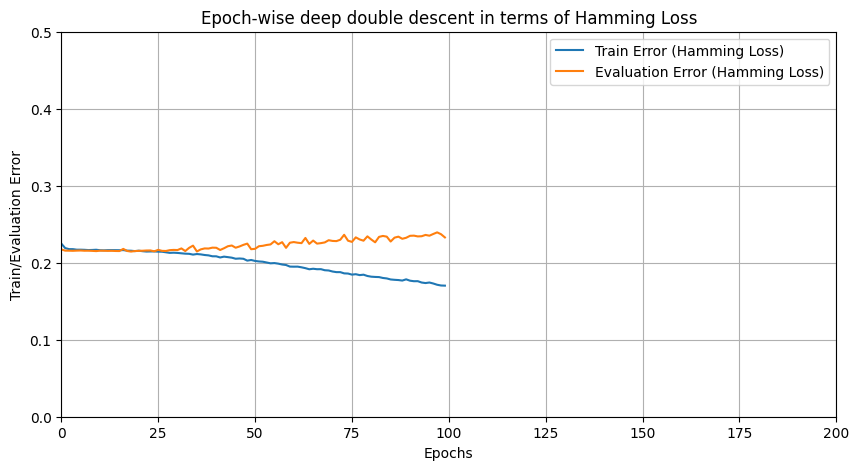

In [ ]:
# Plot for epoch wise deep double descent in terms of hamming loss
plt.figure(figsize=(10, 5))
plt.plot(history.history["Hamming_loss"], label="Train Error (Hamming Loss)")
plt.plot(history.history["val_Hamming_loss"], label="Evaluation Error (Hamming Loss)")
plt.title("Epoch-wise deep double descent in terms of Hamming Loss")
plt.xlabel("Epochs")
plt.ylabel("Train/Evaluation Error")
plt.xlim(0, 100)
plt.ylim(0.0, 0.5)
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

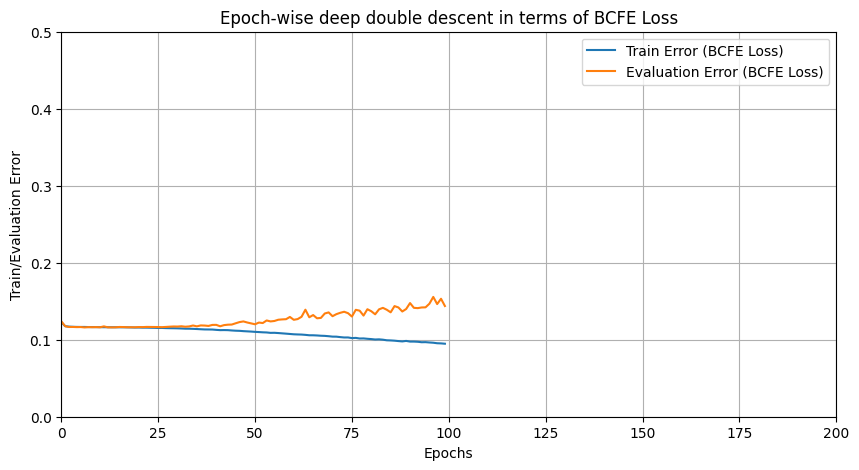

In [ ]:
# Plot for epoch wise deep double descent in terms of BCFE loss
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Train Error (BCFE Loss)")
plt.plot(history.history["val_loss"], label="Evaluation Error (BCFE Loss)")
plt.title("Epoch-wise deep double descent in terms of BCFE Loss")
plt.xlabel("Epochs")
plt.ylabel("Train/Evaluation Error")
plt.xlim(0, 100)
plt.ylim(0.0, 0.5)
plt.legend(loc="upper right")
plt.grid(True)
plt.show()